In [1]:
import networkx as nx
import matplotlib.pyplot as plt

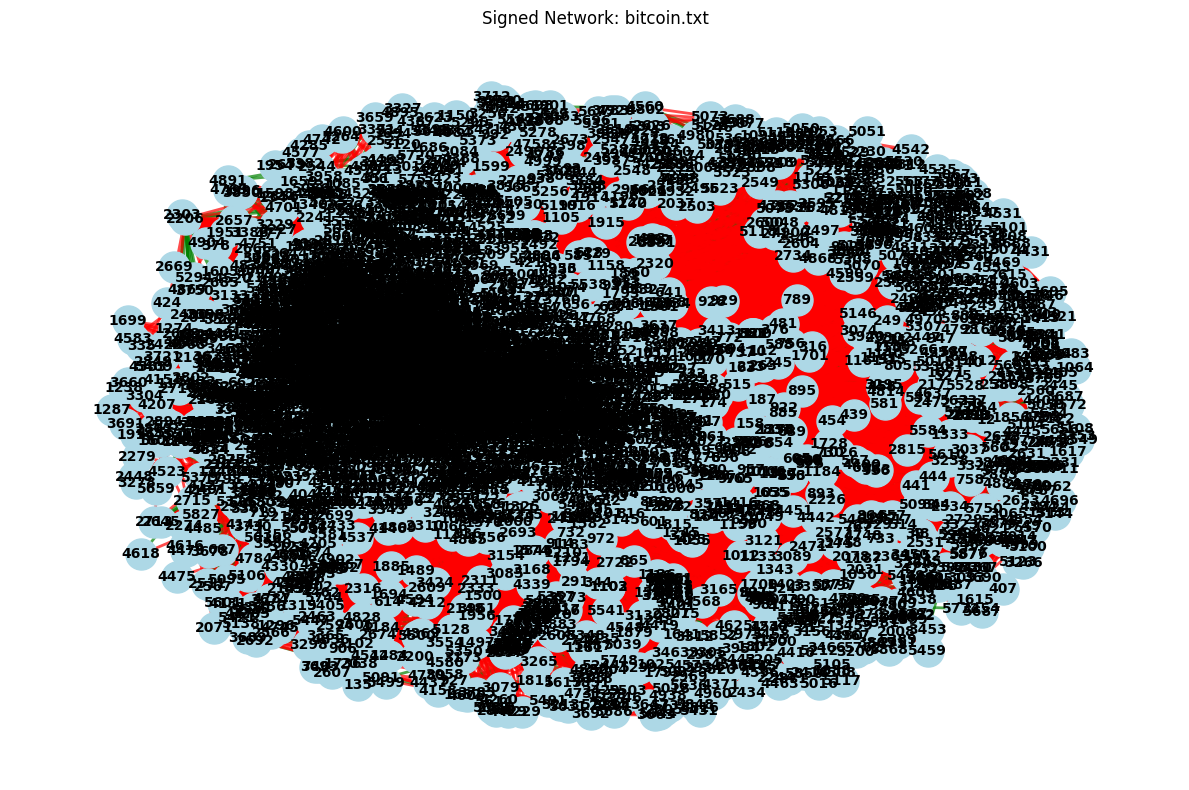

Number of nodes: 5881
Number of edges: 21492
Number of positive edges: 18233
Number of negative edges: 3259


In [10]:
file = 'bitcoin.txt' # an edge list, m lines in total, each line is a tuple (u, v, w)

G = nx.Graph()

with open(file, 'r') as f:
    for line in f:
        # Skip comment lines starting with #
        if line.strip().startswith('#'):
            continue
        # Parse each line as u, v, weight
        parts = line.strip().split('\t')
        if len(parts) == 3:
            u, v, weight = int(parts[0]), int(parts[1]), float(parts[2])
            G.add_edge(u, v, weight=weight)

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)  # Use fixed seed for reproducible layout

# Draw edges with different colors based on weight
positive_edges = [(u, v) for (u, v, d) in G.edges(data=True) if d['weight'] > 0]
negative_edges = [(u, v) for (u, v, d) in G.edges(data=True) if d['weight'] < 0]

# Draw positive edges in green
nx.draw_networkx_edges(G, pos, edgelist=positive_edges, edge_color='green', width=2, alpha=0.7)
# Draw negative edges in red
nx.draw_networkx_edges(G, pos, edgelist=negative_edges, edge_color='red', width=2, alpha=0.7)

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

plt.title(f'Signed Network: {file}')
plt.axis('off')
pos = nx.spring_layout(G, seed=42)  # Replace this line with forceatlas2
plt.tight_layout()
plt.show()

# Print some basic information about the graph
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print(f"Number of positive edges: {len(positive_edges)}")
print(f"Number of negative edges: {len(negative_edges)}")
